In [47]:
import pandas as pd
from sklearn.datasets import load_iris
iris = load_iris()
df = pd.DataFrame(data=iris.data, columns=iris.feature_names)
df['Species'] = iris.target
df['Species'] = df['Species'].map(lambda x: iris.target_names[x])
df = df.rename(columns={
    'sepal length (cm)': 'SepalLengthCm',
    'sepal width (cm)': 'SepalWidthCm',
    'petal length (cm)': 'PetalLengthCm',
    'petal width (cm)': 'PetalWidthCm'
})

print("Loaded Iris dataset from scikit-learn:")
display(df.head())

Loaded Iris dataset from scikit-learn:


,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [48]:
display(df)

,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,virginica
146,6.3,2.5,5.0,1.9,virginica
147,6.5,3.0,5.2,2.0,virginica
148,6.2,3.4,5.4,2.3,virginica


In [49]:
print(type(df))
display(df.info())

<class 'pandas.core.frame.DataFrame'>
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   SepalLengthCm  150 non-null    float64
 1   SepalWidthCm   150 non-null    float64
 2   PetalLengthCm  150 non-null    float64
 3   PetalWidthCm   150 non-null    float64
 4   Species        150 non-null    object 
dtypes: float64(4), object(1)
memory usage: 6.0+ KB


None

In [50]:
print("Descriptive statistics for numerical features:")
display(df.describe())

Descriptive statistics for numerical features:


,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333
std,0.828066,0.435866,1.765298,0.762238
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


In [51]:
print("Missing values in each column:")
display(df.isnull().sum())

Missing values in each column:


,0
SepalLengthCm,0
SepalWidthCm,0
PetalLengthCm,0
PetalWidthCm,0
Species,0


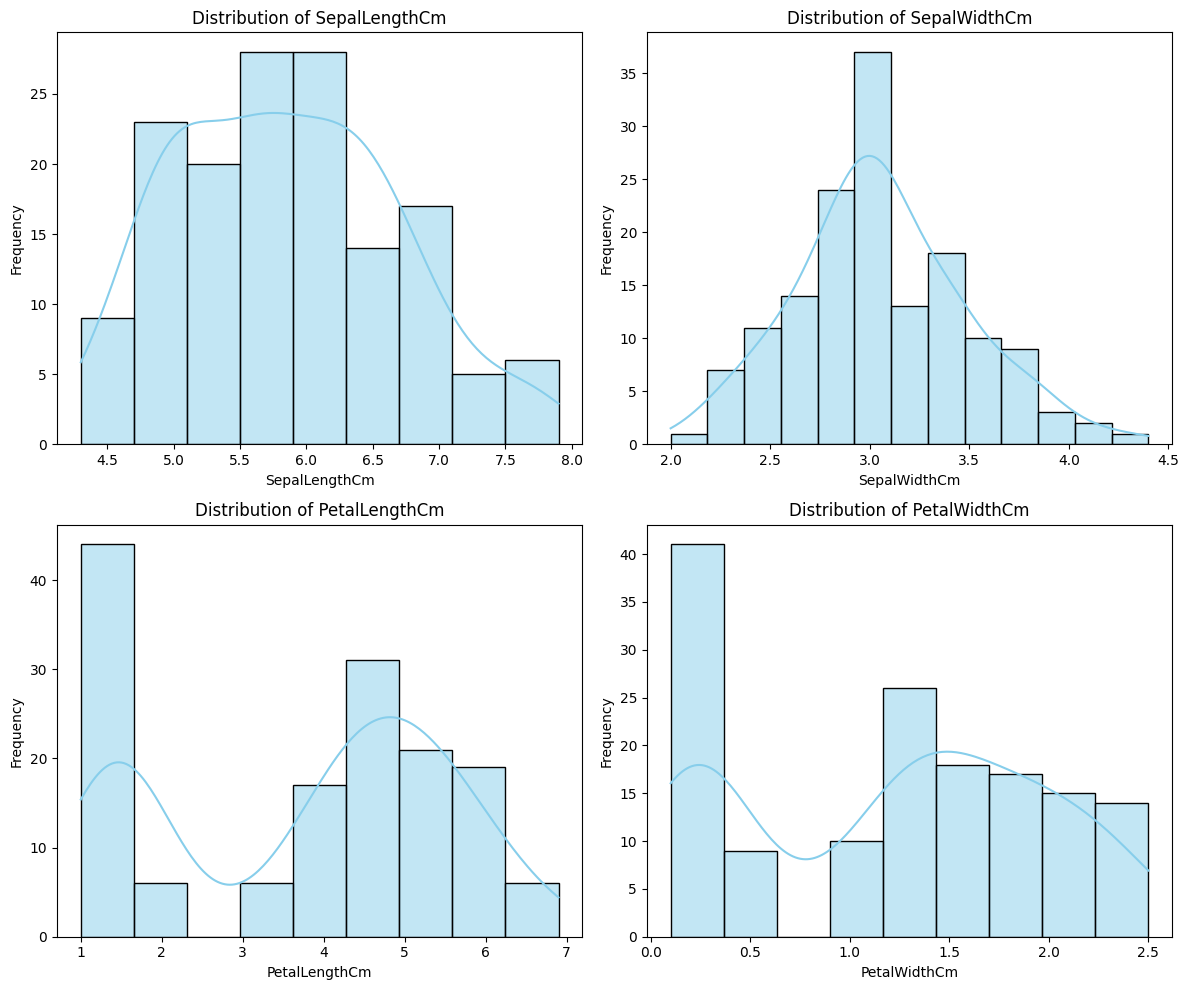

In [52]:
import matplotlib.pyplot as plt
import seaborn as sns
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()
for i, col in enumerate(df.select_dtypes(include=['float64']).columns):
    sns.histplot(df[col], kde=True, ax=axes[i], color='skyblue')
    axes[i].set_title(f'Distribution of {col}')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

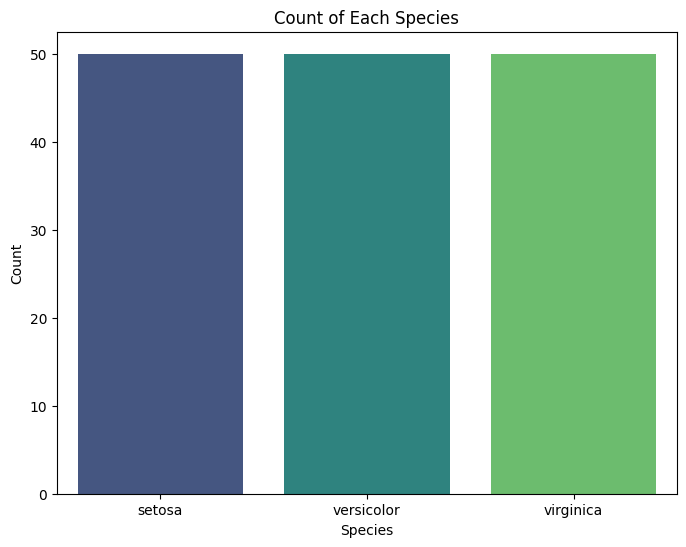

In [54]:
import matplotlib.pyplot as plt
import seaborn as sns
fig = plt.figure(figsize=(8, 6))
sns.countplot(x='Species', data=df, palette='viridis', hue='Species', legend=False)
plt.title('Count of Each Species')
plt.xlabel('Species')
plt.ylabel('Count')
plt.show()

In [55]:

duplicate_rows = df.duplicated().sum()
print(f"Number of duplicate rows found: {duplicate_rows}")

if duplicate_rows > 0:
    df_cleaned = df.drop_duplicates()
    print(f"DataFrame shape before removing duplicates: {df.shape}")
    print(f"DataFrame shape after removing duplicates: {df_cleaned.shape}")
    df = df_cleaned.copy() # Explicitly create a copy to avoid SettingWithCopyWarning
    print("Duplicate rows removed.")
else:
    print("No duplicate rows found.")

display(df.head())

Number of duplicate rows found: 1
DataFrame shape before removing duplicates: (150, 5)
DataFrame shape after removing duplicates: (149, 5)
Duplicate rows removed.


,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [56]:
print("Current data types of each column:")
display(df.info())

Current data types of each column:
<class 'pandas.core.frame.DataFrame'>
Index: 149 entries, 0 to 149
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   SepalLengthCm  149 non-null    float64
 1   SepalWidthCm   149 non-null    float64
 2   PetalLengthCm  149 non-null    float64
 3   PetalWidthCm   149 non-null    float64
 4   Species        149 non-null    object 
dtypes: float64(4), object(1)
memory usage: 7.0+ KB


None

In [57]:
print("\nAnalyzing categorical columns:")
categorical_cols = df.select_dtypes(include=['object', 'category']).columns

if len(categorical_cols) == 0:
    print("No categorical columns found.")
else:
    for col in categorical_cols:
        print(f"\nColumn '{col}':")
        print("Unique values and their counts:")
        display(df[col].value_counts())
        print("Number of unique values:", df[col].nunique())


Analyzing categorical columns:

Column 'Species':
Unique values and their counts:


,count
Species,
setosa,50
versicolor,50
virginica,49


Number of unique values: 3


In [59]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
df['Species_encoded'] = le.fit_transform(df['Species'])

print("Original Species column vs. Encoded Species column:")
display(df[['Species', 'Species_encoded']].head())

print("\nUnique values of original Species:", df['Species'].unique())
print("Unique values of encoded Species:", df['Species_encoded'].unique())

print("Data cleaning process complete. The DataFrame is now ready for further analysis or model building.")

Original Species column vs. Encoded Species column:


,Species,Species_encoded
0,setosa,0
1,setosa,0
2,setosa,0
3,setosa,0
4,setosa,0



Unique values of original Species: [np.str_('setosa') np.str_('versicolor') np.str_('virginica')]
Unique values of encoded Species: [0 1 2]
Data cleaning process complete. The DataFrame is now ready for further analysis or model building.


In [60]:
from sklearn.model_selection import train_test_split
from sklearn.feature_selection import SelectKBest, chi2

X = df.drop(['Species', 'Species_encoded'], axis=1)
y = df['Species_encoded']

X_train_full, X_test_full, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=0)

print(f"Shape of X_train_full (before selection): {X_train_full.shape}")
print(f"Shape of X_test_full (before selection): {X_test_full.shape}")
print("Data successfully split into training and testing sets for feature selection.")

k_features = 4
selector = SelectKBest(chi2, k=k_features)

X_train_transformed = selector.fit_transform(X_train_full, y_train)
X_test_transformed = selector.transform(X_test_full)

selected_feature_indices = selector.get_support(indices=True)
selected_feature_names = X.columns[selected_feature_indices]

# Convert the transformed arrays back to DataFrames with feature names
X_train = pd.DataFrame(X_train_transformed, columns=selected_feature_names, index=X_train_full.index)
X_test = pd.DataFrame(X_test_transformed, columns=selected_feature_names, index=X_test_full.index)

print(f"Original number of features: {X_train_full.shape[1]}")
print(f"Number of features after selection: {X_train.shape[1]}")
print(f"Selected features: {list(selected_feature_names)}")

print("\nShape of X_train:", X_train.shape)
print("Shape of X_test:", X_test.shape)

print("Feature selection complete. The datasets now contain the selected features.")

Shape of X_train_full (before selection): (111, 4)
Shape of X_test_full (before selection): (38, 4)
Data successfully split into training and testing sets for feature selection.
Original number of features: 4
Number of features after selection: 4
Selected features: ['SepalLengthCm', 'SepalWidthCm', 'PetalLengthCm', 'PetalWidthCm']

Shape of X_train: (111, 4)
Shape of X_test: (38, 4)
Feature selection complete. The datasets now contain the selected features.


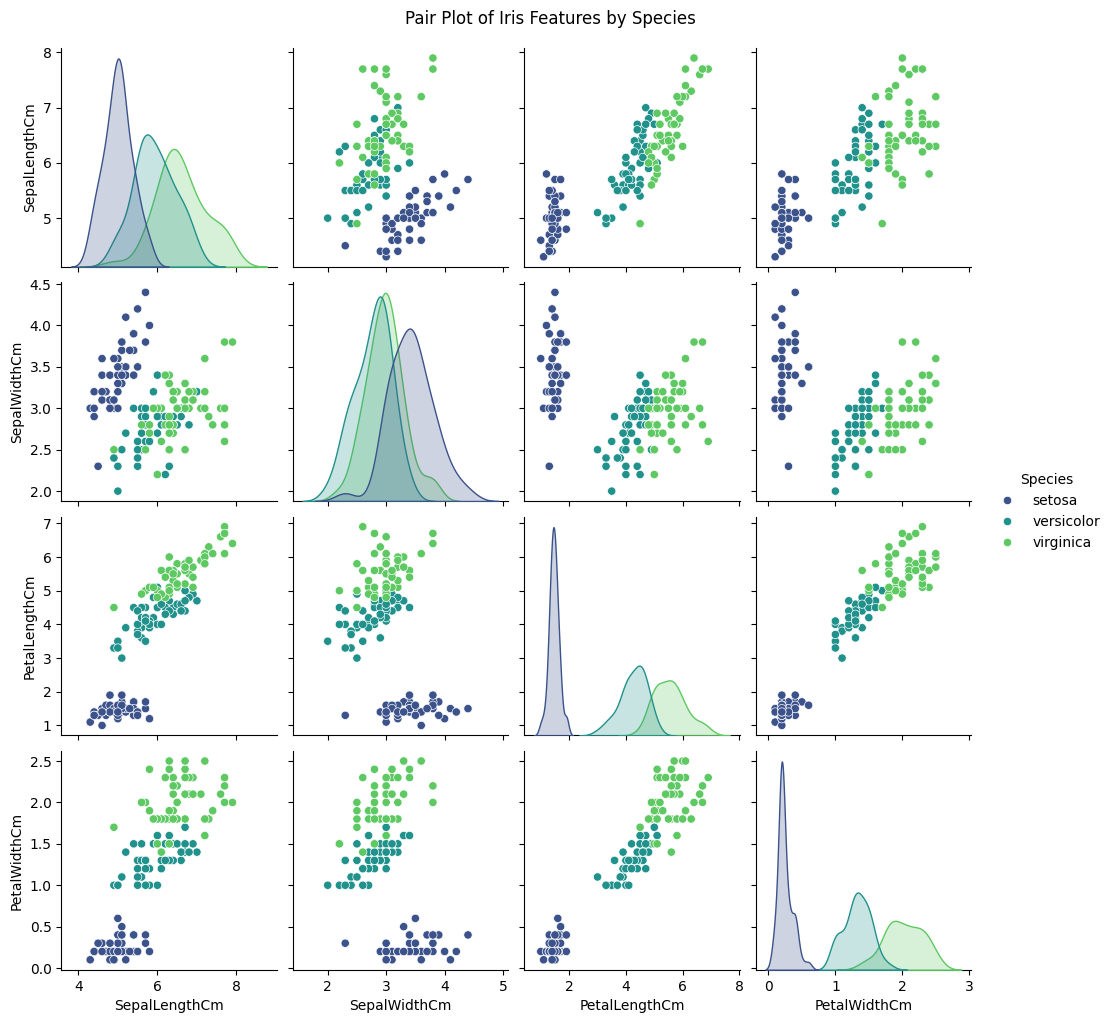

In [61]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.pairplot(df.drop('Species_encoded', axis=1), hue='Species', palette='viridis')
plt.suptitle('Pair Plot of Iris Features by Species', y=1.02)
plt.show()

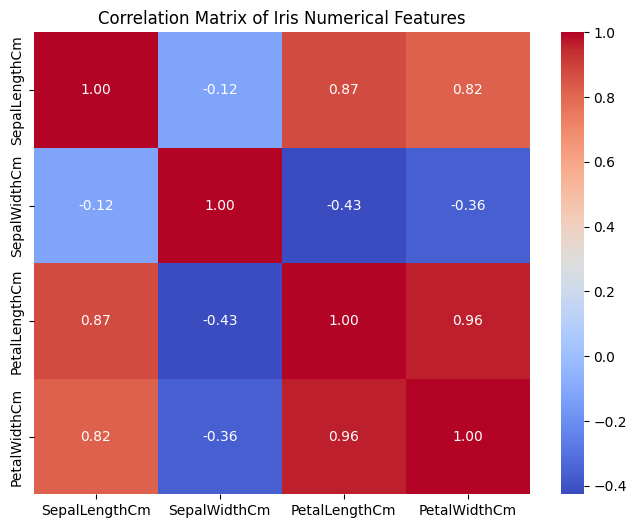

In [62]:
import seaborn as sns
import matplotlib.pyplot as plt

# Calculate the correlation matrix for numerical features
correlation_matrix = df.drop(['Species', 'Species_encoded'], axis=1).corr()

plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix of Iris Numerical Features')
plt.show()

In [63]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
model = LogisticRegression(max_iter=200, random_state=42)
model.fit(X_train, y_train)

print("Model training complete.")

Model training complete.


Accuracy: 1.0000

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        14
           1       1.00      1.00      1.00        14
           2       1.00      1.00      1.00        10

    accuracy                           1.00        38
   macro avg       1.00      1.00      1.00        38
weighted avg       1.00      1.00      1.00        38


Confusion Matrix:


array([[14,  0,  0],
       [ 0, 14,  0],
       [ 0,  0, 10]])

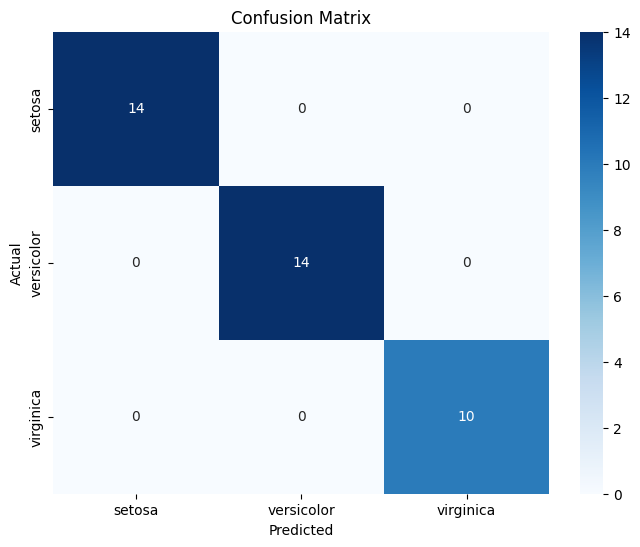

In [64]:
import matplotlib.pyplot as plt
import seaborn as sns
y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred))
conf_matrix = confusion_matrix(y_test, y_pred)
print("\nConfusion Matrix:")
display(conf_matrix)
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues',
            xticklabels=df['Species'].unique(), yticklabels=df['Species'].unique())
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

In [65]:
new_flower_data = pd.DataFrame([[5.0, 3.4, 1.4, 0.3]], columns=selected_feature_names)

print("New flower data:")
display(new_flower_data)
predicted_species_encoded = model.predict(new_flower_data)
predicted_species_name = le.inverse_transform(predicted_species_encoded)

print(f"\nPredicted species (encoded): {predicted_species_encoded[0]}")
print(f"Predicted species: {predicted_species_name[0]}")

New flower data:


,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm
0,5.0,3.4,1.4,0.3



Predicted species (encoded): 0
Predicted species: setosa
